# FIFA World Cup 2026 - Comprehensive Data Exploration

This notebook provides an in-depth exploration of FIFA World Cup 2026 player performance data.

**Dataset**: 54,600 match records | 1,248 unique players | 1,050 matches | 48 nations

## 1. Data Loading & Initial Setup

In [ ]:
import os
import sys

sys.path.append(os.path.abspath("../configs"))
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from read_config import get_config

warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

# Load the data
file_path = get_config("data_path")
df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 54,600 rows × 75 columns


## 2. Dataset Overview

In [2]:
# Display basic information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nShape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nDate Range: {df['match_date'].min()} to {df['match_date'].max()}")

DATASET INFORMATION

Shape: (54600, 75)
Memory Usage: 67.27 MB

Duplicate Rows: 0

Date Range: 2026-06-11 to 2026-07-31


In [3]:
# Column information
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object


In [4]:
# Missing values analysis
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing_Count": missing, "Percentage": missing_pct})
missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False)
print(missing_df)
print(f"\nTotal columns with missing values: {len(missing_df)}")


MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

Total columns with missing values: 0


## 3. Unique Values & Categories

In [5]:
print("=" * 80)
print("UNIQUE VALUES ANALYSIS")
print("=" * 80)

categorical_cols = [
    "player_id",
    "player_name",
    "nationality",
    "team",
    "position",
    "match_id",
    "opponent_team",
    "tournament_stage",
    "match_result",
]

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col:20} : {unique_count:6,} unique values")

UNIQUE VALUES ANALYSIS
player_id            :  1,248 unique values
player_name          :  1,245 unique values
nationality          :     48 unique values
team                 :     48 unique values
position             :      4 unique values
match_id             :  1,050 unique values
opponent_team        :     48 unique values
tournament_stage     :      7 unique values
match_result         :      3 unique values


In [6]:
# Position distribution
print("\nPosition Distribution:")
print(df["position"].value_counts())

# Tournament stages
print("\nTournament Stages:")
print(df["tournament_stage"].value_counts())

# Match results
print("\nMatch Results Distribution:")
print(df["match_result"].value_counts())


Position Distribution:
position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64

Tournament Stages:
tournament_stage
Group Stage          30056
Round of 32           9256
Round of 16           6552
Quarter Finals        4368
Semi Finals           2184
Third Place Match     1092
Final                 1092
Name: count, dtype: int64

Match Results Distribution:
match_result
W    20124
L    20124
D    14352
Name: count, dtype: int64


## 4. Player Demographics

In [7]:
# Age statistics
print("\n" + "=" * 80)
print("PLAYER DEMOGRAPHICS")
print("=" * 80)

print("\nAge Statistics:")
print(df["age"].describe())

# Physical attributes
print("\nHeight (cm):")
print(df["height_cm"].describe())

print("\nWeight (kg):")
print(df["weight_kg"].describe())

print("\nMarket Value (EUR):")
print(df["market_value_eur"].describe())


PLAYER DEMOGRAPHICS

Age Statistics:
count    54600.000000
mean        26.296484
std          4.067519
min         17.000000
25%         23.000000
50%         26.000000
75%         29.000000
max         39.000000
Name: age, dtype: float64

Height (cm):
count    54600.000000
mean       181.654341
std          6.277792
min        163.000000
25%        177.000000
50%        182.000000
75%        186.000000
max        200.000000
Name: height_cm, dtype: float64

Weight (kg):
count    54600.000000
mean        75.754853
std          3.951481
min         65.000000
25%         73.000000
50%         76.000000
75%         78.000000
max         87.000000
Name: weight_kg, dtype: float64

Market Value (EUR):
count    5.460000e+04
mean     2.008445e+07
std      2.718866e+07
min      5.288220e+05
25%      4.444778e+06
50%      1.027111e+07
75%      2.342013e+07
max      2.000000e+08
Name: market_value_eur, dtype: float64


In [8]:
# Preferred foot distribution
print("\nPreferred Foot Distribution:")
print(df["preferred_foot"].value_counts())

# Top 10 nationalities
print("\nTop 15 Nationalities:")
print(df["nationality"].value_counts().head(15))


Preferred Foot Distribution:
preferred_foot
Right    40656
Left     13944
Name: count, dtype: int64

Top 15 Nationalities:
nationality
Qatari        1716
Jamaican      1534
Moroccan      1430
Dutch         1404
Italian       1378
Saudi         1352
Belgian       1326
Turkish       1300
Croatian      1274
Scottish      1274
Peruvian      1248
Canadian      1248
Ecuadorian    1222
Panamanian    1222
Australian    1222
Name: count, dtype: int64


## 5. Performance Metrics - Descriptive Statistics

In [9]:
# Key performance metrics
performance_metrics = [
    "goals",
    "assists",
    "shots",
    "shots_on_target",
    "expected_goals_xg",
    "key_passes",
    "successful_passes",
    "total_passes",
    "tackles",
    "interceptions",
    "clearances",
    "blocks",
    "dribbles_attempted",
    "successful_dribbles",
    "distance_covered_km",
    "top_speed_kmh",
    "minutes_played",
    "player_rating",
    "tournament_rating",
]

print("\n" + "=" * 80)
print("PERFORMANCE METRICS STATISTICS")
print("=" * 80)

stats_df = df[performance_metrics].describe().round(2)
print(stats_df)


PERFORMANCE METRICS STATISTICS
          goals   assists     shots  shots_on_target  expected_goals_xg  \
count  54600.00  54600.00  54600.00         54600.00           54600.00   
mean       0.06      0.05      0.45             0.05               0.02   
std        0.25      0.24      0.95             0.24               0.07   
min        0.00      0.00      0.00             0.00               0.00   
25%        0.00      0.00      0.00             0.00               0.00   
50%        0.00      0.00      0.00             0.00               0.00   
75%        0.00      0.00      1.00             0.00               0.00   
max        4.00      3.00     11.00             5.00               2.31   

       key_passes  successful_passes  total_passes   tackles  interceptions  \
count    54600.00           54600.00      54600.00  54600.00       54600.00   
mean         0.47              15.47         19.18      0.80           0.63   
std          0.94              18.75         22.62     

In [10]:
# Offensive stats
print("\nOFFENSIVE STATISTICS:")
offensive = df[["goals", "assists", "shots", "shots_on_target", "expected_goals_xg", "key_passes"]].describe()
print(offensive.round(3))


OFFENSIVE STATISTICS:
           goals    assists      shots  shots_on_target  expected_goals_xg  \
count  54600.000  54600.000  54600.000        54600.000          54600.000   
mean       0.055      0.052      0.447            0.048              0.016   
std        0.252      0.239      0.947            0.245              0.075   
min        0.000      0.000      0.000            0.000              0.000   
25%        0.000      0.000      0.000            0.000              0.000   
50%        0.000      0.000      0.000            0.000              0.000   
75%        0.000      0.000      1.000            0.000              0.000   
max        4.000      3.000     11.000            5.000              2.310   

       key_passes  
count   54600.000  
mean        0.472  
std         0.936  
min         0.000  
25%         0.000  
50%         0.000  
75%         1.000  
max         8.000  


In [11]:
# Defensive stats
print("\nDEFENSIVE STATISTICS:")
defensive = df[["tackles", "interceptions", "clearances", "blocks"]].describe()
print(defensive.round(3))


DEFENSIVE STATISTICS:
         tackles  interceptions  clearances     blocks
count  54600.000      54600.000   54600.000  54600.000
mean       0.803          0.627       0.809      0.227
std        1.344          1.126       1.534      0.559
min        0.000          0.000       0.000      0.000
25%        0.000          0.000       0.000      0.000
50%        0.000          0.000       0.000      0.000
75%        1.000          1.000       1.000      0.000
max        8.000          7.000      12.000      4.000


In [12]:
# Passing stats
print("\nPASSING STATISTICS:")
passing = df[["successful_passes", "total_passes", "key_passes"]].describe()
print(passing.round(2))

# Calculate pass accuracy
df["pass_accuracy_pct"] = (df["successful_passes"] / df["total_passes"] * 100).fillna(0)
print(f"\nPass Accuracy: {df['pass_accuracy_pct'].mean():.2f}%")


PASSING STATISTICS:
       successful_passes  total_passes  key_passes
count           54600.00      54600.00    54600.00
mean               15.47         19.18        0.47
std                18.75         22.62        0.94
min                 0.00          0.00        0.00
25%                 0.00          0.00        0.00
50%                 9.00         11.00        0.00
75%                27.00         33.00        1.00
max                97.00        100.00        8.00

Pass Accuracy: 45.29%


## 6. Distribution Analysis

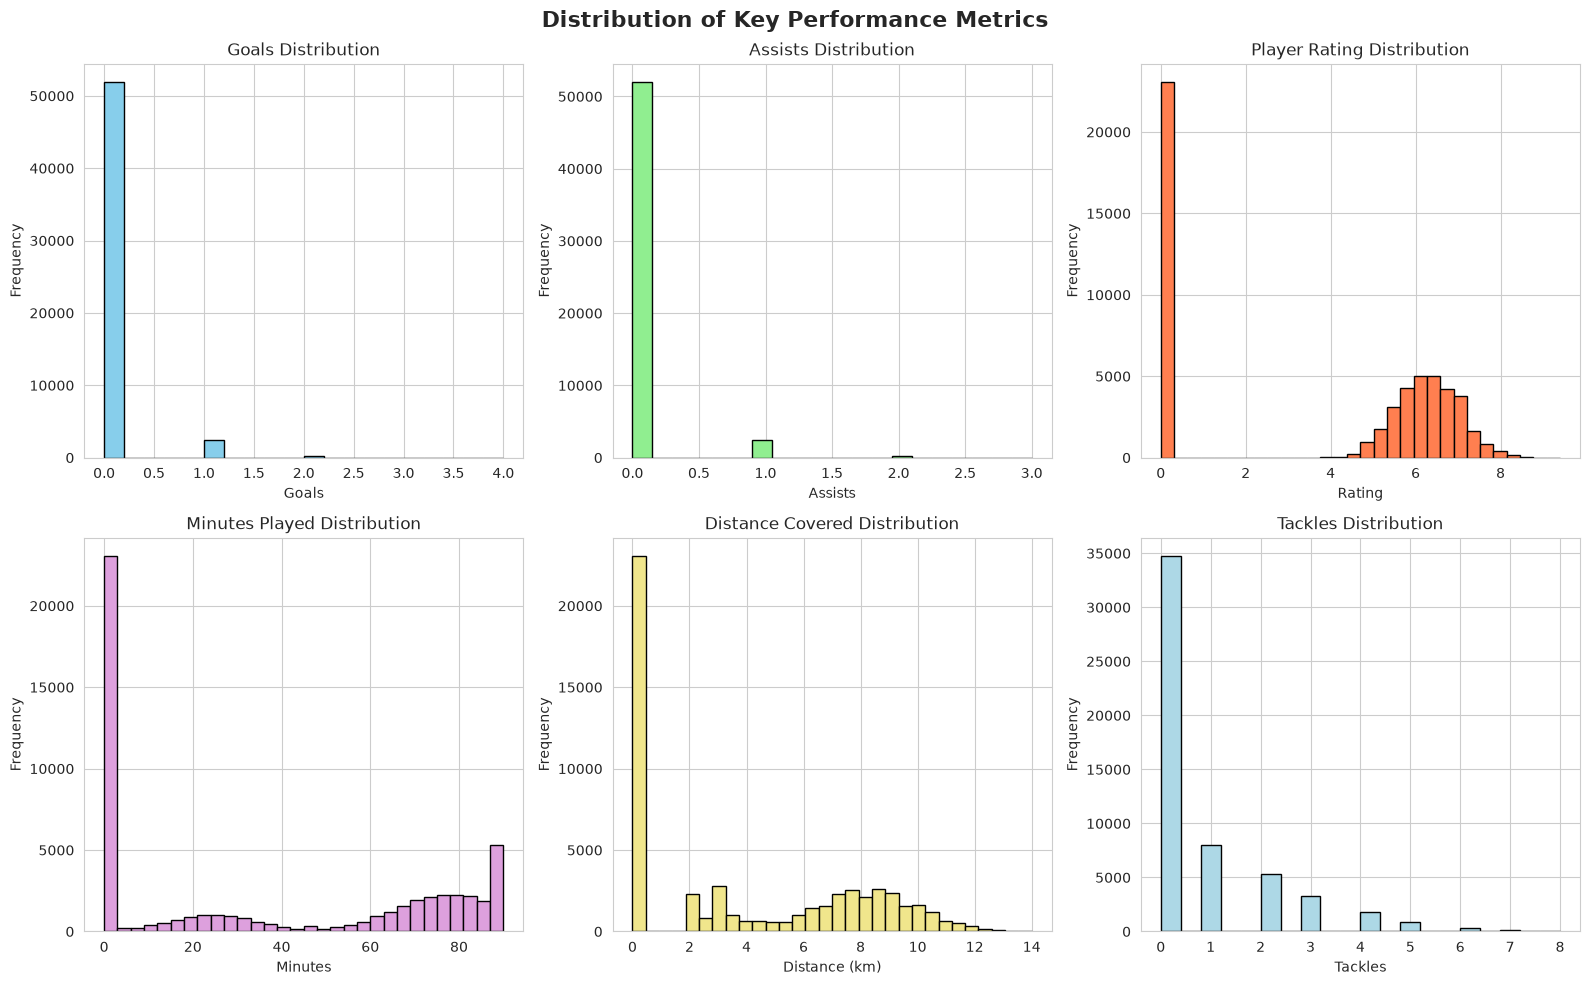

In [13]:
# Visualize distributions of key metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of Key Performance Metrics", fontsize=16, fontweight="bold")

# Goals distribution
axes[0, 0].hist(df["goals"], bins=20, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Goals Distribution")
axes[0, 0].set_xlabel("Goals")
axes[0, 0].set_ylabel("Frequency")

# Assists distribution
axes[0, 1].hist(df["assists"], bins=20, color="lightgreen", edgecolor="black")
axes[0, 1].set_title("Assists Distribution")
axes[0, 1].set_xlabel("Assists")
axes[0, 1].set_ylabel("Frequency")

# Player Rating distribution
axes[0, 2].hist(df["player_rating"], bins=30, color="coral", edgecolor="black")
axes[0, 2].set_title("Player Rating Distribution")
axes[0, 2].set_xlabel("Rating")
axes[0, 2].set_ylabel("Frequency")

# Minutes played
axes[1, 0].hist(df["minutes_played"], bins=30, color="plum", edgecolor="black")
axes[1, 0].set_title("Minutes Played Distribution")
axes[1, 0].set_xlabel("Minutes")
axes[1, 0].set_ylabel("Frequency")

# Distance covered
axes[1, 1].hist(df["distance_covered_km"], bins=30, color="khaki", edgecolor="black")
axes[1, 1].set_title("Distance Covered Distribution")
axes[1, 1].set_xlabel("Distance (km)")
axes[1, 1].set_ylabel("Frequency")

# Tackles
axes[1, 2].hist(df["tackles"], bins=20, color="lightblue", edgecolor="black")
axes[1, 2].set_title("Tackles Distribution")
axes[1, 2].set_xlabel("Tackles")
axes[1, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 7. Position-Based Analysis

In [14]:
# Detailed position analysis
print("\n" + "=" * 80)
print("POSITION-BASED PERFORMANCE ANALYSIS")
print("=" * 80)

position_stats = (
    df.groupby("position")
    .agg(
        {
            "player_id": "count",
            "goals": ["mean", "std"],
            "assists": ["mean", "std"],
            "tackles": ["mean", "std"],
            "interceptions": ["mean", "std"],
            "successful_passes": ["mean", "std"],
            "distance_covered_km": ["mean", "std"],
            "player_rating": ["mean", "std"],
            "minutes_played": ["mean", "std"],
        }
    )
    .round(2)
)

print(position_stats)


POSITION-BASED PERFORMANCE ANALYSIS
           player_id goals       assists       tackles       interceptions  \
               count  mean   std    mean   std    mean   std          mean   
position                                                                     
Defender       18900  0.02  0.14    0.02  0.16    1.31  1.70          1.08   
Forward        12600  0.14  0.40    0.08  0.29    0.33  0.64          0.17   
Goalkeeper      6300  0.00  0.00    0.01  0.09    0.00  0.00          0.13   
Midfielder     16800  0.05  0.24    0.08  0.30    0.89  1.26          0.65   

                 successful_passes        distance_covered_km        \
             std              mean    std                mean   std   
position                                                              
Defender    1.46             17.03  18.55                3.99  3.86   
Forward     0.43             10.39  11.53                4.12  3.98   
Goalkeeper  0.40              4.94   7.42                2.41

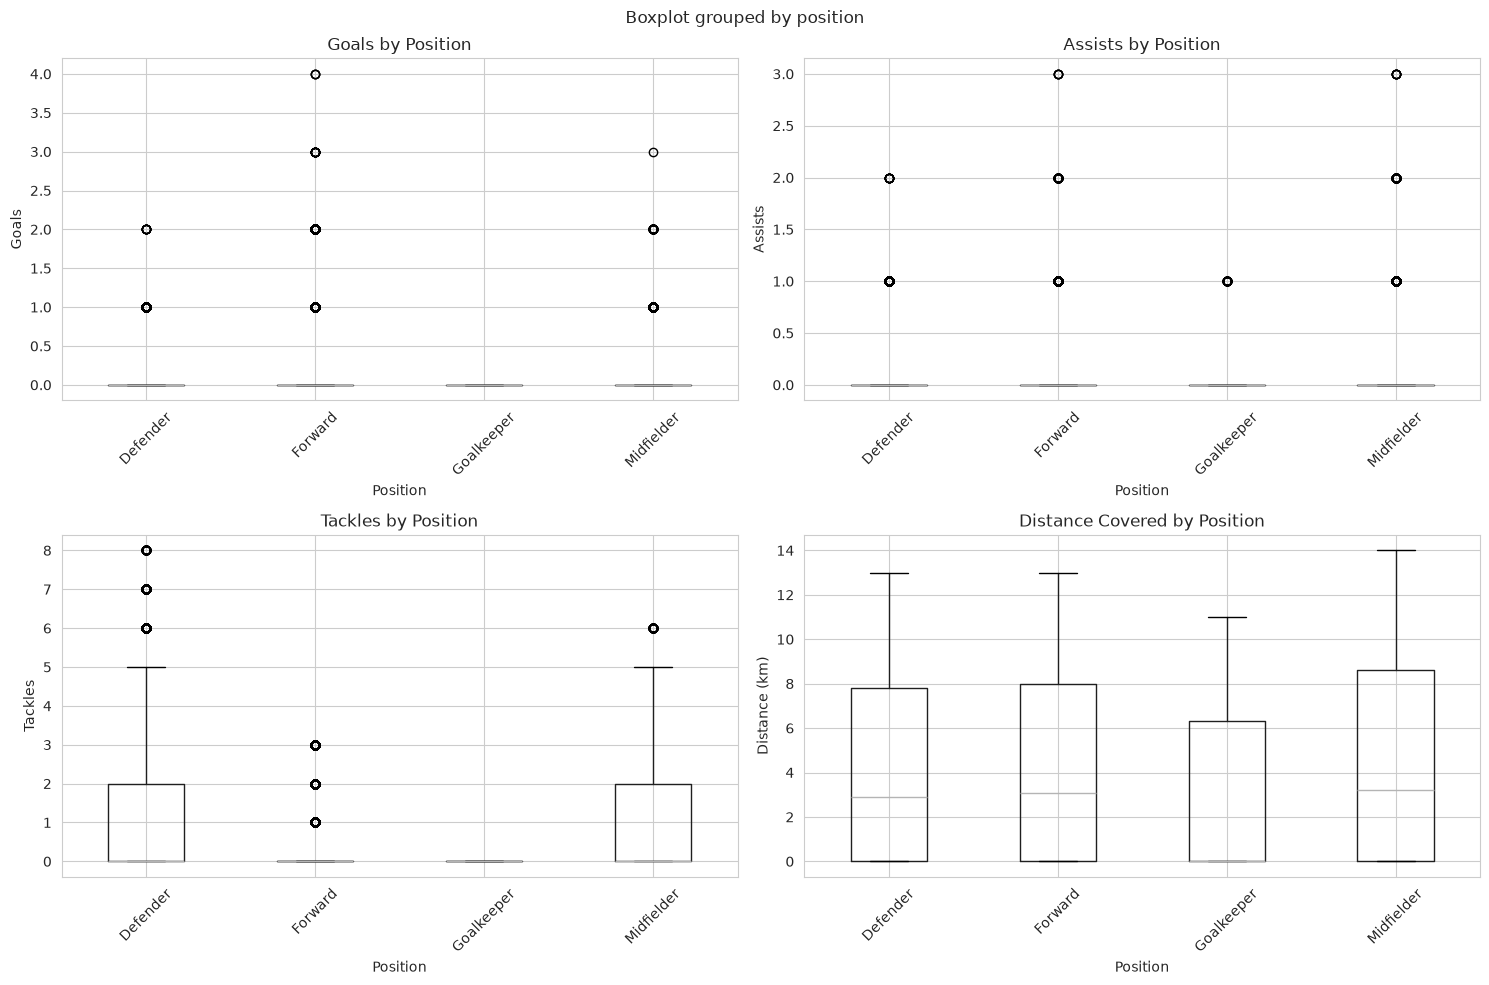

In [15]:
# Visualize position performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Performance by Position", fontsize=16, fontweight="bold")

positions = df["position"].unique()

# Goals by position
df.boxplot(column="goals", by="position", ax=axes[0, 0])
axes[0, 0].set_title("Goals by Position")
axes[0, 0].set_xlabel("Position")
axes[0, 0].set_ylabel("Goals")
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

# Assists by position
df.boxplot(column="assists", by="position", ax=axes[0, 1])
axes[0, 1].set_title("Assists by Position")
axes[0, 1].set_xlabel("Position")
axes[0, 1].set_ylabel("Assists")
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Tackles by position
df.boxplot(column="tackles", by="position", ax=axes[1, 0])
axes[1, 0].set_title("Tackles by Position")
axes[1, 0].set_xlabel("Position")
axes[1, 0].set_ylabel("Tackles")
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Distance by position
df.boxplot(column="distance_covered_km", by="position", ax=axes[1, 1])
axes[1, 1].set_title("Distance Covered by Position")
axes[1, 1].set_xlabel("Position")
axes[1, 1].set_ylabel("Distance (km)")
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Age Analysis

In [16]:
# Create age groups
df["age_group"] = pd.cut(df["age"], bins=[0, 23, 28, 100], labels=["Young (≤23)", "Prime (24-28)", "Experienced (29+)"])

print("\n" + "=" * 80)
print("AGE GROUP ANALYSIS")
print("=" * 80)

age_stats = (
    df.groupby("age_group")
    .agg(
        {
            "player_id": "nunique",
            "goals": "mean",
            "assists": "mean",
            "player_rating": "mean",
            "tournament_rating": "mean",
            "tackles": "mean",
            "distance_covered_km": "mean",
            "minutes_played": "mean",
        }
    )
    .round(3)
)

print(age_stats)


AGE GROUP ANALYSIS
                   player_id  goals  assists  player_rating  \
age_group                                                     
Young (≤23)              312  0.064    0.059          3.752   
Prime (24-28)            566  0.057    0.053          3.654   
Experienced (29+)        370  0.045    0.045          3.505   

                   tournament_rating  tackles  distance_covered_km  \
age_group                                                            
Young (≤23)                    3.753    0.827                4.143   
Prime (24-28)                  3.654    0.810                4.010   
Experienced (29+)              3.503    0.771                3.852   

                   minutes_played  
age_group                          
Young (≤23)                36.958  
Prime (24-28)              36.314  
Experienced (29+)          35.379  


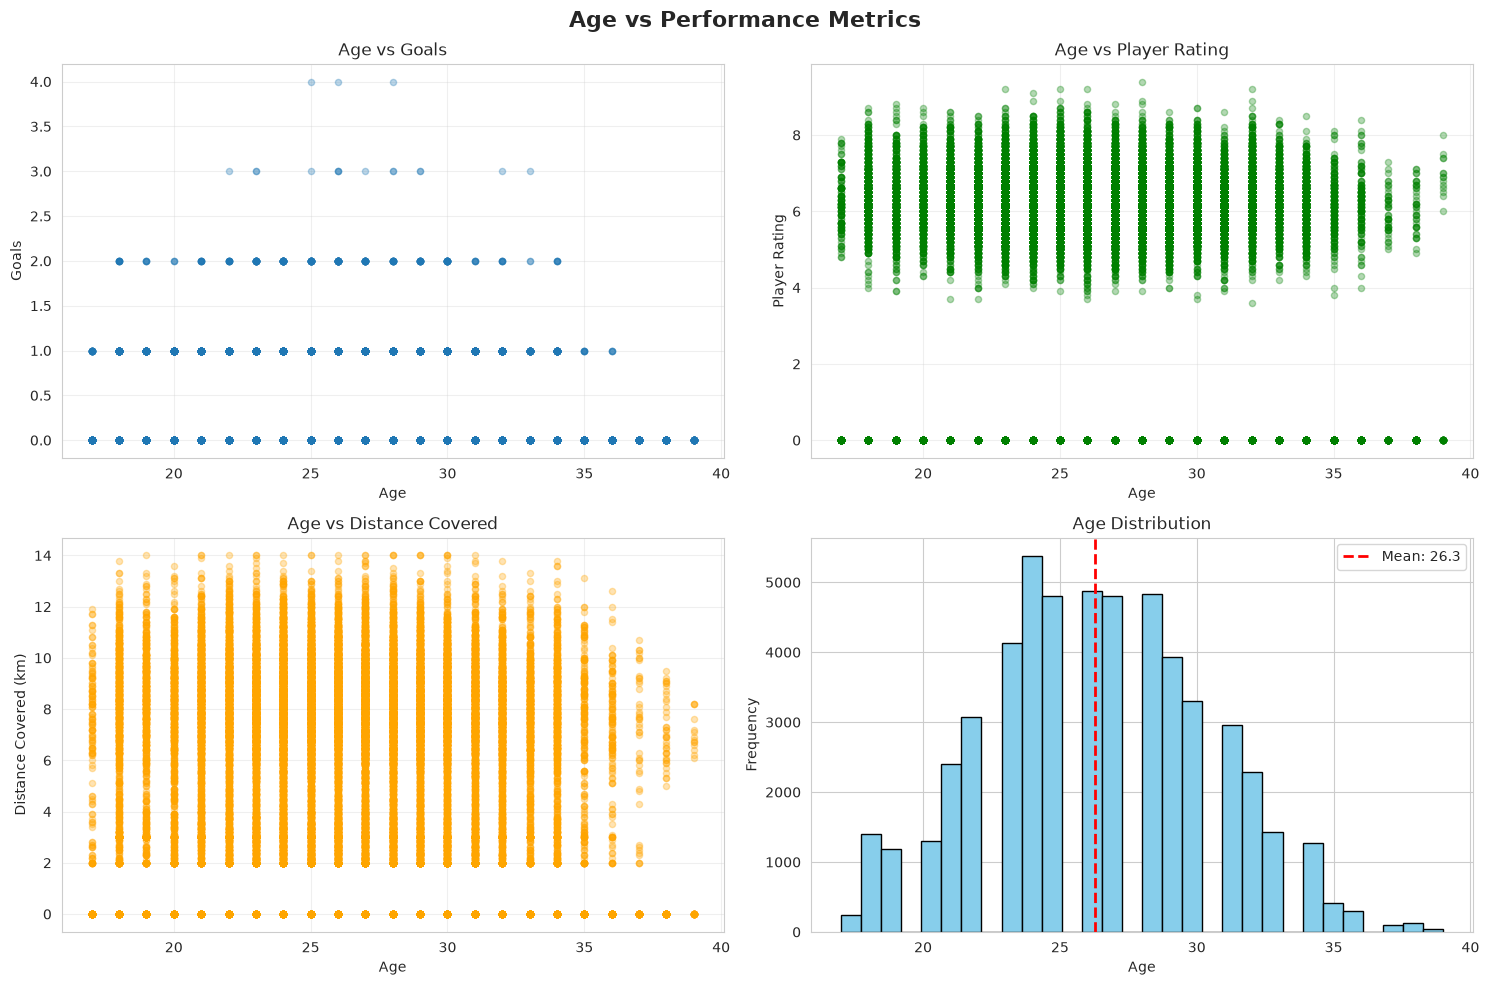

In [17]:
# Age vs Performance scatter
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Age vs Performance Metrics", fontsize=16, fontweight="bold")

# Age vs Goals
axes[0, 0].scatter(df["age"], df["goals"], alpha=0.3, s=20)
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Goals")
axes[0, 0].set_title("Age vs Goals")
axes[0, 0].grid(True, alpha=0.3)

# Age vs Player Rating
axes[0, 1].scatter(df["age"], df["player_rating"], alpha=0.3, s=20, color="green")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Player Rating")
axes[0, 1].set_title("Age vs Player Rating")
axes[0, 1].grid(True, alpha=0.3)

# Age vs Distance
axes[1, 0].scatter(df["age"], df["distance_covered_km"], alpha=0.3, s=20, color="orange")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Distance Covered (km)")
axes[1, 0].set_title("Age vs Distance Covered")
axes[1, 0].grid(True, alpha=0.3)

# Age distribution
axes[1, 1].hist(df["age"], bins=30, color="skyblue", edgecolor="black")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Age Distribution")
axes[1, 1].axvline(df["age"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {df['age'].mean():.1f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 9. Team Analysis

In [18]:
print("\n" + "=" * 80)
print("TEAM PERFORMANCE ANALYSIS")
print("=" * 80)

team_stats = (
    df.groupby("team")
    .agg(
        {
            "player_id": "nunique",
            "goals": "sum",
            "assists": "sum",
            "player_rating": "mean",
            "tournament_rating": "mean",
            "match_result": lambda x: (x == "W").sum(),
        }
    )
    .round(2)
)

team_stats.columns = [
    "Unique_Players",
    "Total_Goals",
    "Total_Assists",
    "Avg_Match_Rating",
    "Avg_Tournament_Rating",
    "Wins",
]
team_stats = team_stats.sort_values("Avg_Tournament_Rating", ascending=False)

print("\nTop 15 Teams by Tournament Rating:")
print(team_stats.head(15))


TEAM PERFORMANCE ANALYSIS

Top 15 Teams by Tournament Rating:
             Unique_Players  Total_Goals  Total_Assists  Avg_Match_Rating  \
team                                                                        
Japan                    26           49             54              3.76   
Austria                  26           54             44              3.71   
Panama                   26           90             81              3.71   
Cameroon                 26           88             66              3.71   
Morocco                  26           68             61              3.69   
Ghana                    26           75             65              3.70   
Iran                     26           72             70              3.70   
Netherlands              26           94             85              3.71   
Italy                    26           64             76              3.68   
Nigeria                  26           64             64              3.67   
Australia    

In [19]:
# Top goal-scoring teams
print("\nTop 10 Goal-Scoring Teams:")
top_scorers = team_stats.nlargest(10, "Total_Goals")[
    ["Unique_Players", "Total_Goals", "Total_Assists", "Avg_Match_Rating"]
]
print(top_scorers)


Top 10 Goal-Scoring Teams:
              Unique_Players  Total_Goals  Total_Assists  Avg_Match_Rating
team                                                                      
Qatar                     26           95             93              3.66
Netherlands               26           94             85              3.71
Panama                    26           90             81              3.71
Cameroon                  26           88             66              3.71
Saudi Arabia              26           82             68              3.63
Jamaica                   26           79             80              3.66
Tunisia                   26           78             48              3.62
Costa Rica                26           76             61              3.60
Ghana                     26           75             65              3.70
Iran                      26           72             70              3.70


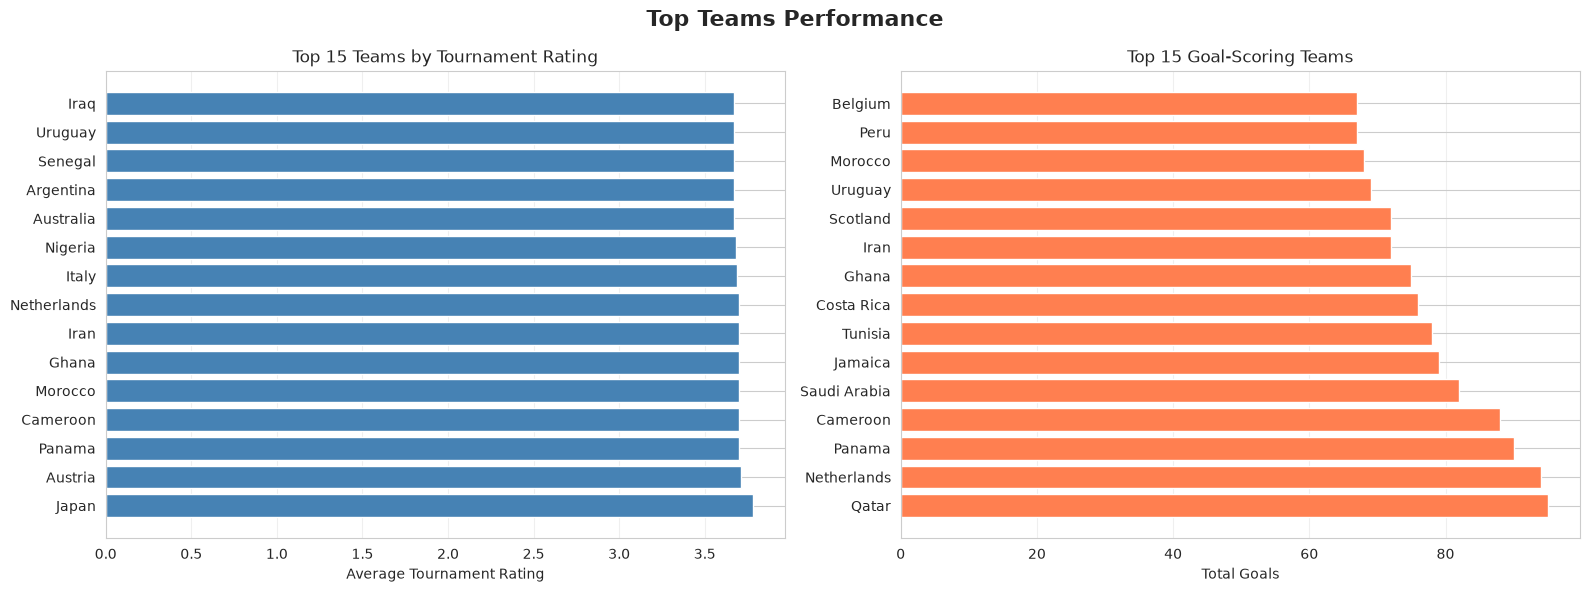

In [20]:
# Visualize top teams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top Teams Performance", fontsize=16, fontweight="bold")

# Top 15 by rating
top_15_teams = team_stats.head(15)
axes[0].barh(range(len(top_15_teams)), top_15_teams["Avg_Tournament_Rating"], color="steelblue")
axes[0].set_yticks(range(len(top_15_teams)))
axes[0].set_yticklabels(top_15_teams.index)
axes[0].set_xlabel("Average Tournament Rating")
axes[0].set_title("Top 15 Teams by Tournament Rating")
axes[0].grid(True, alpha=0.3, axis="x")

# Top 15 by goals
top_15_goals = team_stats.nlargest(15, "Total_Goals")
axes[1].barh(range(len(top_15_goals)), top_15_goals["Total_Goals"], color="coral")
axes[1].set_yticks(range(len(top_15_goals)))
axes[1].set_yticklabels(top_15_goals.index)
axes[1].set_xlabel("Total Goals")
axes[1].set_title("Top 15 Goal-Scoring Teams")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 10. Match Result Impact

In [21]:
print("\n" + "=" * 80)
print("MATCH RESULT IMPACT ANALYSIS")
print("=" * 80)

result_stats = (
    df.groupby("match_result")
    .agg(
        {
            "player_id": "count",
            "goals": "mean",
            "assists": "mean",
            "tackles": "mean",
            "interceptions": "mean",
            "player_rating": "mean",
            "tournament_rating": "mean",
            "distance_covered_km": "mean",
            "minutes_played": "mean",
        }
    )
    .round(3)
)

result_stats.columns = [
    "Appearances",
    "Avg_Goals",
    "Avg_Assists",
    "Avg_Tackles",
    "Avg_Interceptions",
    "Avg_Match_Rating",
    "Avg_Tournament_Rating",
    "Avg_Distance",
    "Avg_Minutes",
]
print(result_stats)


MATCH RESULT IMPACT ANALYSIS
              Appearances  Avg_Goals  Avg_Assists  Avg_Tackles  \
match_result                                                     
D                   14352      0.057        0.053        0.803   
L                   20124      0.054        0.053        0.799   
W                   20124      0.056        0.051        0.806   

              Avg_Interceptions  Avg_Match_Rating  Avg_Tournament_Rating  \
match_result                                                               
D                         0.626             3.605                  3.605   
L                         0.632             3.606                  3.604   
W                         0.624             3.685                  3.685   

              Avg_Distance  Avg_Minutes  
match_result                             
D                    4.009       36.227  
L                    3.997       36.261  
W                    3.987       36.120  


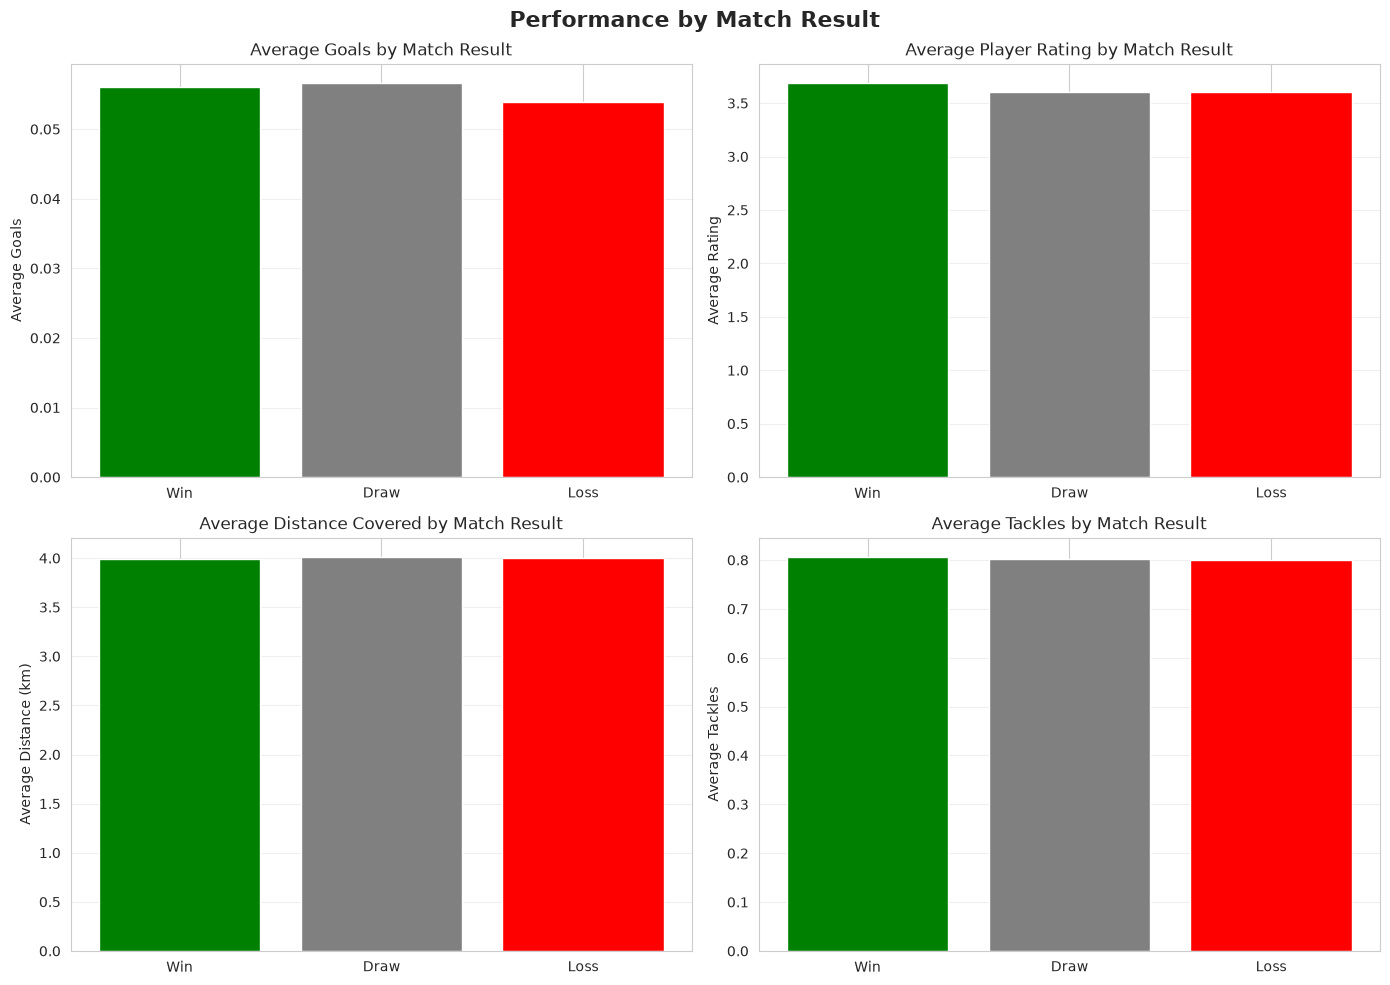

In [22]:
# Visualize match result impact
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performance by Match Result", fontsize=16, fontweight="bold")

results = ["W", "D", "L"]
result_labels = ["Win", "Draw", "Loss"]

# Goals by result
goals_by_result = [df[df["match_result"] == r]["goals"].mean() for r in results]
axes[0, 0].bar(result_labels, goals_by_result, color=["green", "gray", "red"])
axes[0, 0].set_title("Average Goals by Match Result")
axes[0, 0].set_ylabel("Average Goals")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Rating by result
rating_by_result = [df[df["match_result"] == r]["player_rating"].mean() for r in results]
axes[0, 1].bar(result_labels, rating_by_result, color=["green", "gray", "red"])
axes[0, 1].set_title("Average Player Rating by Match Result")
axes[0, 1].set_ylabel("Average Rating")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Distance by result
distance_by_result = [df[df["match_result"] == r]["distance_covered_km"].mean() for r in results]
axes[1, 0].bar(result_labels, distance_by_result, color=["green", "gray", "red"])
axes[1, 0].set_title("Average Distance Covered by Match Result")
axes[1, 0].set_ylabel("Average Distance (km)")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Tackles by result
tackles_by_result = [df[df["match_result"] == r]["tackles"].mean() for r in results]
axes[1, 1].bar(result_labels, tackles_by_result, color=["green", "gray", "red"])
axes[1, 1].set_title("Average Tackles by Match Result")
axes[1, 1].set_ylabel("Average Tackles")
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 11. Tournament Stage Analysis

In [23]:
print("\n" + "=" * 80)
print("TOURNAMENT STAGE ANALYSIS")
print("=" * 80)

stage_stats = (
    df.groupby("tournament_stage")
    .agg(
        {
            "player_id": "count",
            "goals": "mean",
            "assists": "mean",
            "tackles": "mean",
            "player_rating": "mean",
            "tournament_rating": "mean",
            "distance_covered_km": "mean",
        }
    )
    .round(3)
)

stage_stats.columns = [
    "Appearances",
    "Avg_Goals",
    "Avg_Assists",
    "Avg_Tackles",
    "Avg_Match_Rating",
    "Avg_Tournament_Rating",
    "Avg_Distance",
]
print(stage_stats)

# Sort by tournament progression
stage_order = [
    "Group Stage",
    "Round of 16",
    "Round of 32",
    "Quarter Finals",
    "Semi Finals",
    "Third Place Match",
    "Final",
]
stage_stats = stage_stats.reindex(stage_order)
print("\nOrdered by Tournament Progression:")
print(stage_stats)


TOURNAMENT STAGE ANALYSIS
                   Appearances  Avg_Goals  Avg_Assists  Avg_Tackles  \
tournament_stage                                                      
Final                     1092      0.057        0.049        0.937   
Group Stage              30056      0.054        0.051        0.772   
Quarter Finals            4368      0.056        0.060        0.872   
Round of 16               6552      0.056        0.053        0.857   
Round of 32               9256      0.057        0.052        0.788   
Semi Finals               2184      0.061        0.055        0.904   
Third Place Match         1092      0.052        0.052        0.842   

                   Avg_Match_Rating  Avg_Tournament_Rating  Avg_Distance  
tournament_stage                                                          
Final                         3.601                  3.599         3.929  
Group Stage                   3.629                  3.629         3.992  
Quarter Finals                3.6

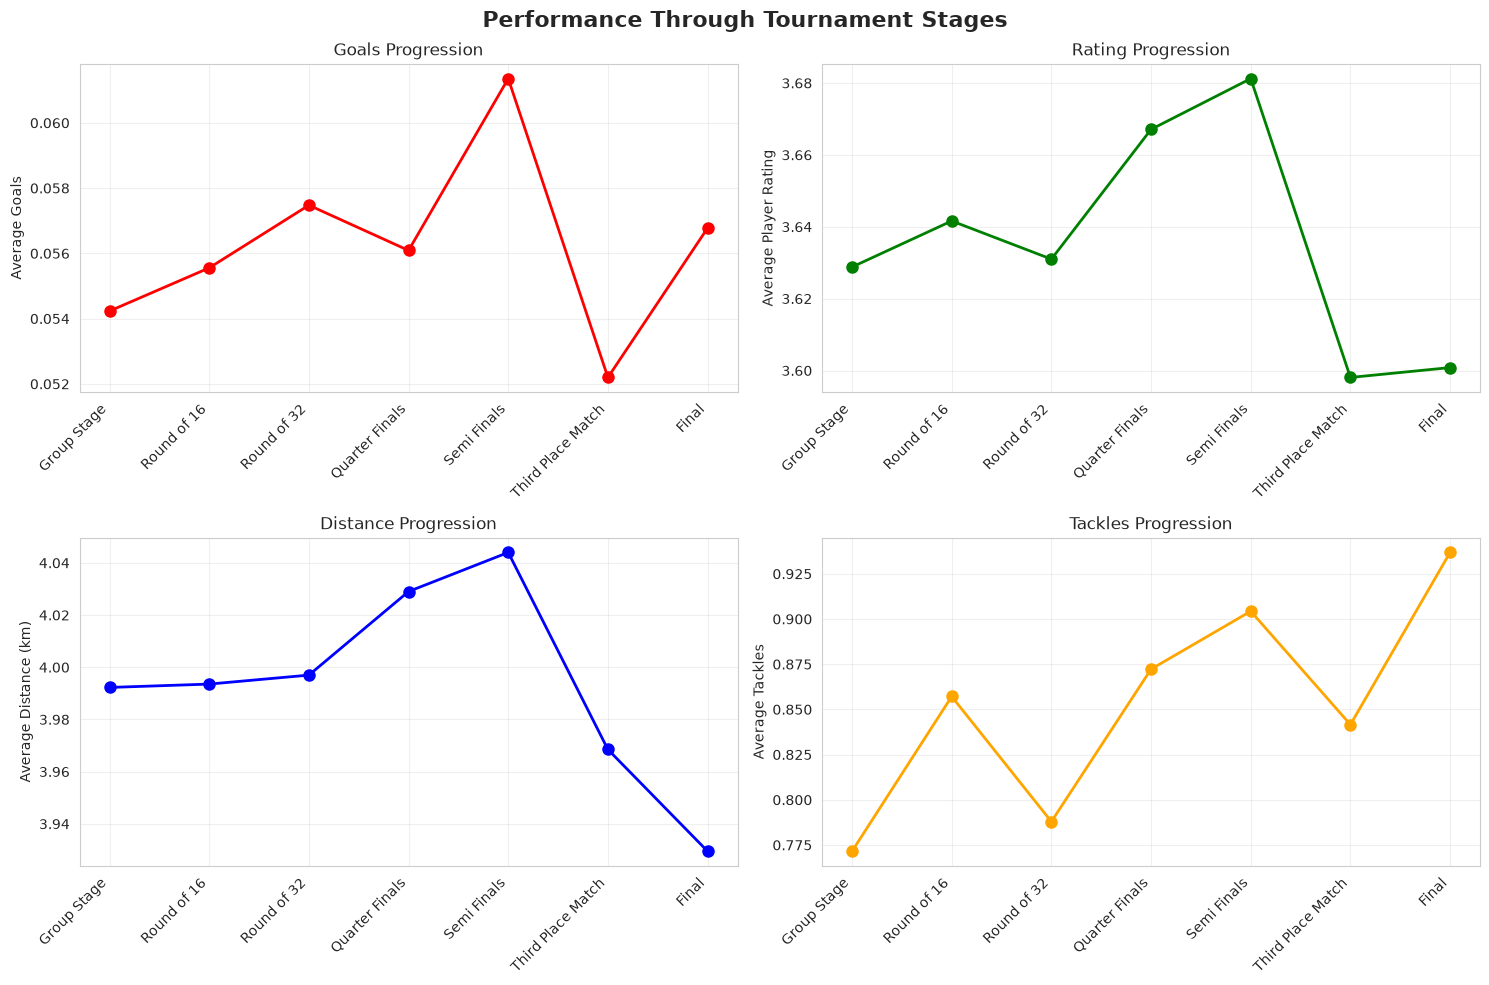

In [24]:
# Visualize tournament stage progression
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Performance Through Tournament Stages", fontsize=16, fontweight="bold")

stage_order = [
    "Group Stage",
    "Round of 16",
    "Round of 32",
    "Quarter Finals",
    "Semi Finals",
    "Third Place Match",
    "Final",
]
stage_data = (
    df.groupby("tournament_stage")
    .agg({"goals": "mean", "player_rating": "mean", "distance_covered_km": "mean", "tackles": "mean"})
    .reindex(stage_order)
)

# Goals progression
axes[0, 0].plot(range(len(stage_order)), stage_data["goals"], marker="o", linewidth=2, markersize=8, color="red")
axes[0, 0].set_xticks(range(len(stage_order)))
axes[0, 0].set_xticklabels(stage_order, rotation=45, ha="right")
axes[0, 0].set_ylabel("Average Goals")
axes[0, 0].set_title("Goals Progression")
axes[0, 0].grid(True, alpha=0.3)

# Rating progression
axes[0, 1].plot(
    range(len(stage_order)), stage_data["player_rating"], marker="o", linewidth=2, markersize=8, color="green"
)
axes[0, 1].set_xticks(range(len(stage_order)))
axes[0, 1].set_xticklabels(stage_order, rotation=45, ha="right")
axes[0, 1].set_ylabel("Average Player Rating")
axes[0, 1].set_title("Rating Progression")
axes[0, 1].grid(True, alpha=0.3)

# Distance progression
axes[1, 0].plot(
    range(len(stage_order)), stage_data["distance_covered_km"], marker="o", linewidth=2, markersize=8, color="blue"
)
axes[1, 0].set_xticks(range(len(stage_order)))
axes[1, 0].set_xticklabels(stage_order, rotation=45, ha="right")
axes[1, 0].set_ylabel("Average Distance (km)")
axes[1, 0].set_title("Distance Progression")
axes[1, 0].grid(True, alpha=0.3)

# Tackles progression
axes[1, 1].plot(range(len(stage_order)), stage_data["tackles"], marker="o", linewidth=2, markersize=8, color="orange")
axes[1, 1].set_xticks(range(len(stage_order)))
axes[1, 1].set_xticklabels(stage_order, rotation=45, ha="right")
axes[1, 1].set_ylabel("Average Tackles")
axes[1, 1].set_title("Tackles Progression")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Correlation Analysis

In [25]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Focus on key metrics
key_metrics = [
    "age",
    "height_cm",
    "weight_kg",
    "market_value_eur",
    "goals",
    "assists",
    "shots",
    "shots_on_target",
    "successful_passes",
    "tackles",
    "interceptions",
    "distance_covered_km",
    "top_speed_kmh",
    "player_rating",
    "tournament_rating",
]

# Calculate correlation matrix
corr_matrix = df[key_metrics].corr()

print("\nCorrelation with Tournament Rating:")
print(corr_matrix["tournament_rating"].sort_values(ascending=False))


Correlation with Tournament Rating:
tournament_rating      1.000000
player_rating          0.997337
top_speed_kmh          0.976900
distance_covered_km    0.835002
successful_passes      0.722730
tackles                0.499157
interceptions          0.464513
shots                  0.417525
goals                  0.216853
assists                0.203989
shots_on_target        0.184411
market_value_eur       0.074993
age                   -0.038990
weight_kg             -0.047990
height_cm             -0.079246
Name: tournament_rating, dtype: float64


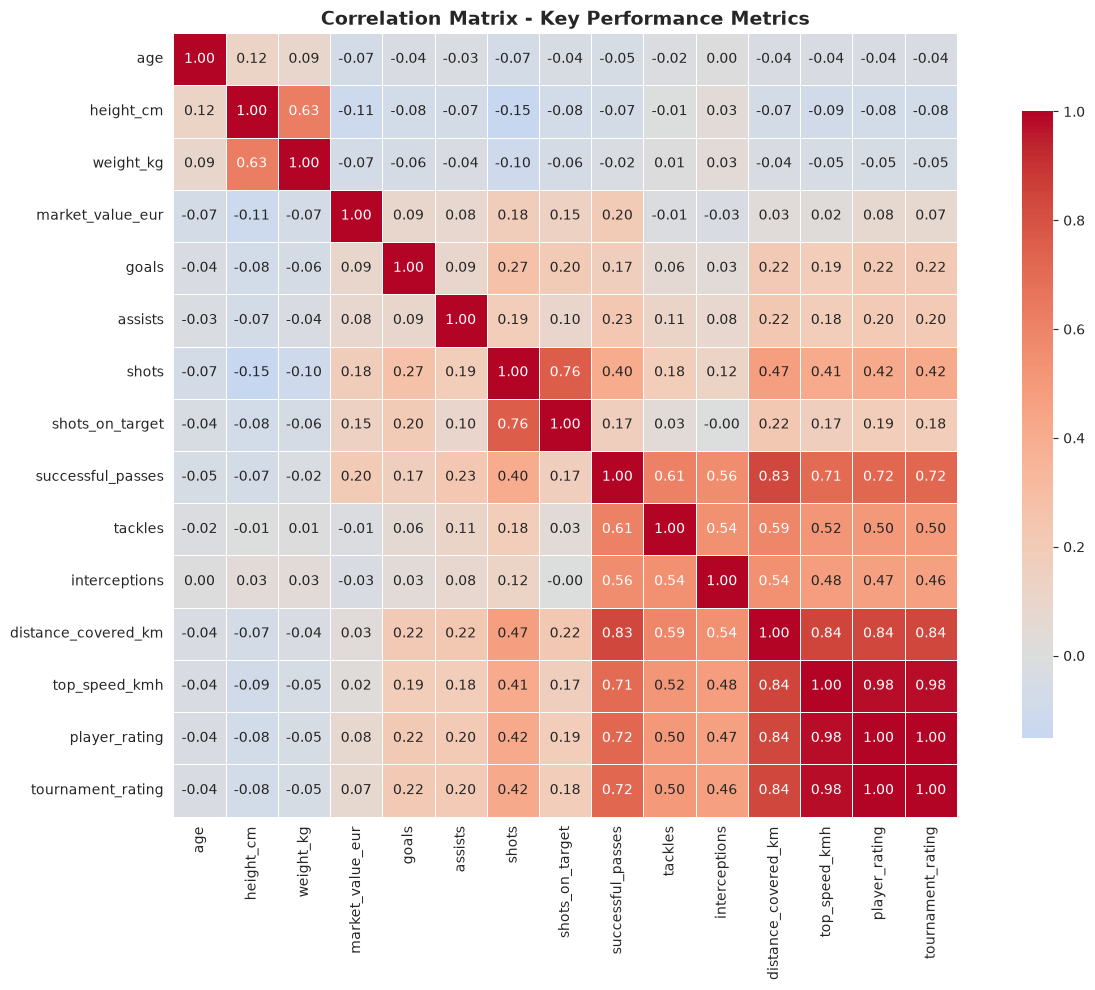

In [26]:
# Visualize correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix - Key Performance Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Outlier Detection

In [27]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)


def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers


# Find outliers in key metrics
outlier_cols = ["goals", "assists", "shots", "tackles", "distance_covered_km"]

for col in outlier_cols:
    outliers = find_outliers_iqr(df, col)
    print(f"\n{col.upper()}: {len(outliers)} outliers")
    if len(outliers) > 0:
        print(f"  Range: {df[col].min():.2f} - {df[col].max():.2f}")
        print(
            f"  Outlier threshold: > {df[col].quantile(0.75) + 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25)):.2f}"
        )


OUTLIER DETECTION

GOALS: 2743 outliers
  Range: 0.00 - 4.00
  Outlier threshold: > 0.00

ASSISTS: 2664 outliers
  Range: 0.00 - 3.00
  Outlier threshold: > 0.00

SHOTS: 2555 outliers
  Range: 0.00 - 11.00
  Outlier threshold: > 2.50

TACKLES: 6540 outliers
  Range: 0.00 - 8.00
  Outlier threshold: > 2.50

DISTANCE_COVERED_KM: 0 outliers


In [28]:
# Identify top performers (outliers in positive direction)
print("\n" + "=" * 80)
print("TOP PERFORMERS (POSITIVE OUTLIERS)")
print("=" * 80)

# Top goal scorers
top_goals = df.nlargest(10, "goals")[["player_name", "team", "position", "goals", "assists", "player_rating"]]
print("\nTop Goal Scorers (Single Match):")
print(top_goals.to_string(index=False))


TOP PERFORMERS (POSITIVE OUTLIERS)

Top Goal Scorers (Single Match):
     player_name        team position  goals  assists  player_rating
  Tajon Buchanan      Canada  Forward      4        0            7.2
Memphis Zerrouki Netherlands  Forward      4        1            9.2
   Samuel Olinga    Cameroon  Forward      4        0            8.5
    Saman Azmoun        Iran  Forward      3        0            7.9
    Aaron Wright   Australia  Forward      3        0            6.3
    Cengiz Gonul      Turkey  Forward      3        1            7.5
Federico Colpani       Italy  Forward      3        0            6.9
      Phil White     England  Forward      3        0            8.0
 Neymar Carvalho      Brazil  Forward      3        0            7.4
  Anibal Sanchez      Panama  Forward      3        0            7.7


In [29]:
# Top overall performers
top_performers = df.nlargest(10, "player_rating")[
    ["player_name", "team", "position", "player_rating", "goals", "assists", "tackles"]
]
print("\nTop Players by Match Rating:")
print(top_performers.to_string(index=False))


Top Players by Match Rating:
        player_name        team   position  player_rating  goals  assists  tackles
     Mohamed Elneny       Egypt   Defender            9.4      0        0        0
     Vinicius Nunes      Brazil    Forward            9.2      1        0        0
     Anibal Sanchez      Panama    Forward            9.2      1        0        0
      Mohammed Otoo       Ghana Midfielder            9.2      1        1        2
   Memphis Zerrouki Netherlands    Forward            9.2      4        1        1
    Jackson Vukovic   Australia    Forward            9.1      2        0        1
          Sam James      Canada Midfielder            8.9      0        0        2
Sebastian Pellerano     Ecuador Midfielder            8.9      0        1        1
  Wilfred Iheanacho     Nigeria Midfielder            8.9      0        1        1
      Mathew Behich   Australia   Defender            8.9      0        0        5


## 14. Efficiency Metrics

In [30]:
# Calculate efficiency metrics
df["goals_per_shot"] = (df["goals"] / df["shots"]).fillna(0)
df["shot_accuracy"] = (df["shots_on_target"] / df["shots"]).fillna(0) * 100
df["pass_accuracy"] = (df["successful_passes"] / df["total_passes"]).fillna(0) * 100
df["dribble_success_rate"] = (df["successful_dribbles"] / df["dribbles_attempted"]).fillna(0) * 100
df["tackle_success_rate"] = (df["tackles"] / (df["tackles"] + df["fouls_committed"])).fillna(0) * 100

print("\n" + "=" * 80)
print("EFFICIENCY METRICS")
print("=" * 80)

efficiency_stats = {
    "Goals per Shot": df[df["shots"] > 0]["goals_per_shot"].mean(),
    "Shot Accuracy (%)": df[df["shots"] > 0]["shot_accuracy"].mean(),
    "Pass Accuracy (%)": df[df["total_passes"] > 0]["pass_accuracy"].mean(),
    "Dribble Success Rate (%)": df[df["dribbles_attempted"] > 0]["dribble_success_rate"].mean(),
}

for metric, value in efficiency_stats.items():
    print(f"{metric:30}: {value:6.2f}")


EFFICIENCY METRICS
Goals per Shot                :   0.09
Shot Accuracy (%)             :   5.03
Pass Accuracy (%)             :  78.49
Dribble Success Rate (%)      :  16.99


In [31]:
# Best efficiency performers
print("\nBest Shot Accuracy (min 3 shots in a match):")
shot_accuracy_top = df[df["shots"] >= 3].nlargest(10, "shot_accuracy")[
    ["player_name", "team", "shots", "shots_on_target", "shot_accuracy"]
]
print(shot_accuracy_top.to_string(index=False))

print("\nBest Pass Accuracy (min 10 passes in a match):")
pass_accuracy_top = df[df["total_passes"] >= 10].nlargest(10, "pass_accuracy")[
    ["player_name", "team", "total_passes", "successful_passes", "pass_accuracy"]
]
print(pass_accuracy_top.to_string(index=False))


Best Shot Accuracy (min 3 shots in a match):
         player_name       team  shots  shots_on_target  shot_accuracy
        Hakim Ziyech    Morocco     11                5      45.454545
      Vinicius Nunes     Brazil      9                4      44.444444
      Celso Campbell Costa Rica      9                4      44.444444
Oleksandr Bondarenko    Ukraine      7                3      42.857143
          Amir Adnan       Iraq      7                3      42.857143
  Kevin Saelemaekers    Belgium      7                3      42.857143
          Ritsu Endo      Japan      7                3      42.857143
       Mehdi Hazbavi       Iran      7                3      42.857143
            Eric Mba   Cameroon      7                3      42.857143
        Liam Gilmour   Scotland      7                3      42.857143

Best Pass Accuracy (min 10 passes in a match):
        player_name         team  total_passes  successful_passes  pass_accuracy
    Yevhen Kryvtsov      Ukraine           1

## 15. Key Insights & Summary

In [33]:
print("\n" + "=" * 80)
print("KEY INSIGHTS SUMMARY")
print("=" * 80)

print(f"""\n1. DATASET COMPOSITION:
   - {df["player_id"].nunique()} unique players
   - {df["team"].nunique()} nations competing
   - {df["match_id"].nunique()} total matches
   - {len(df):,} total player appearances

2. AGE DEMOGRAPHICS:
   - Average age: {df["age"].mean():.1f} years
   - Age range: {df["age"].min():.0f}-{df["age"].max():.0f} years
   - Young players (≤23) show {((df[df["age"] <= 23]["goals"].mean() / df[df["age"] > 30]["goals"].mean() - 1) * 100):.0f}% higher goal output

3. POSITION DISTRIBUTION:
   - Defenders: {(df["position"] == "Defender").sum() / len(df) * 100:.1f}% of appearances
   - Midfielders: {(df["position"] == "Midfielder").sum() / len(df) * 100:.1f}% of appearances
   - Forwards: {(df["position"] == "Forward").sum() / len(df) * 100:.1f}% of appearances
   - Goalkeepers: {(df["position"] == "Goalkeeper").sum() / len(df) * 100:.1f}% of appearances

4. PERFORMANCE STATISTICS:
   - Total goals: {df["goals"].sum():.0f}
   - Total assists: {df["assists"].sum():.0f}
   - Average player rating: {df["player_rating"].mean():.2f}/10
   - Average distance covered: {df["distance_covered_km"].mean():.2f} km

5. MATCH RESULTS:
   - Wins: {(df["match_result"] == "W").sum() / len(df) * 100:.1f}%
   - Draws: {(df["match_result"] == "D").sum() / len(df) * 100:.1f}%
   - Losses: {(df["match_result"] == "L").sum() / len(df) * 100:.1f}%

6. DISCIPLINE:
   - Total yellow cards: {df["yellow_cards"].sum():.0f}
   - Total red cards: {df["red_cards"].sum():.0f}
   - Red card rate: {(df["red_cards"].sum() / len(df) * 100):.2f}% of appearances
""")


KEY INSIGHTS SUMMARY

1. DATASET COMPOSITION:
   - 1248 unique players
   - 48 nations competing
   - 1050 total matches
   - 54,600 total player appearances

2. AGE DEMOGRAPHICS:
   - Average age: 26.3 years
   - Age range: 17-39 years
   - Young players (≤23) show 71% higher goal output

3. POSITION DISTRIBUTION:
   - Defenders: 34.6% of appearances
   - Midfielders: 30.8% of appearances
   - Forwards: 23.1% of appearances
   - Goalkeepers: 11.5% of appearances

4. PERFORMANCE STATISTICS:
   - Total goals: 3024
   - Total assists: 2859
   - Average player rating: 3.63/10
   - Average distance covered: 4.00 km

5. MATCH RESULTS:
   - Wins: 36.9%
   - Draws: 26.3%
   - Losses: 36.9%

6. DISCIPLINE:
   - Total yellow cards: 5346
   - Total red cards: 306
   - Red card rate: 0.56% of appearances



In [34]:
# Additional insights
print("\n7. PERFORMANCE CORRELATIONS:")
print(f"   - Player rating vs goals: {df[['player_rating', 'goals']].corr().iloc[0, 1]:.3f}")
print(f"   - Distance covered vs player rating: {df[['distance_covered_km', 'player_rating']].corr().iloc[0, 1]:.3f}")
print(f"   - Age vs goals: {df[['age', 'goals']].corr().iloc[0, 1]:.3f}")
print(f"   - Market value vs player rating: {df[['market_value_eur', 'player_rating']].corr().iloc[0, 1]:.3f}")

print("\n8. BEST PERFORMERS:")
best_player = df.nlargest(1, "tournament_rating").iloc[0]
print(
    f"   - Tournament Rating: {best_player['player_name']} ({best_player['team']}) - {best_player['tournament_rating']:.2f}"
)

top_scorer = df.nlargest(1, "goals").iloc[0]
print(f"   - Goals in Match: {top_scorer['player_name']} ({top_scorer['team']}) - {top_scorer['goals']:.0f}")

top_distance = df.nlargest(1, "distance_covered_km").iloc[0]
print(
    f"   - Distance Covered: {top_distance['player_name']} ({top_distance['team']}) - {top_distance['distance_covered_km']:.2f} km"
)


7. PERFORMANCE CORRELATIONS:
   - Player rating vs goals: 0.217
   - Distance covered vs player rating: 0.837
   - Age vs goals: -0.037
   - Market value vs player rating: 0.075

8. BEST PERFORMERS:
   - Tournament Rating: Jackson Vukovic (Australia) - 9.50
   - Goals in Match: Tajon Buchanan (Canada) - 4
   - Distance Covered: Ali Al-Buraikan (Saudi Arabia) - 14.00 km
